<a href="https://colab.research.google.com/github/hjiwoong/DL/blob/main/day03_practice1_%ED%8D%BC%EC%85%89%ED%8A%B8%EB%A1%A0_XOR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

plt.rcParams["axes.unicode_minus"] = False
torch.manual_seed(42)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


In [4]:
# 셀 1. 논리 게이트 데이터 - 입력 2개, 출력 1개
X = torch.tensor([[0.0, 0.0],
                  [0.0, 1.0],
                  [1.0, 0.0],
                  [1.0, 1.0]])

y_and = torch.tensor([[0.0], [0.0], [0.0], [0.0]]) # 둘 다 1일 때만 1
y_or = torch.tensor([[0.0], [1.0], [1.0], [1.0]]) # 하나라고 1이면 1
y_xor = torch.tensor([[0.0], [1.0], [1.0], [0.0]]) # 서로 다를 때만 1

print("입력 4가지:", X.shape)
print("XOR 정답:", y_xor.flatten().tolist())

입력 4가지: torch.Size([4, 2])
XOR 정답: [0.0, 1.0, 1.0, 0.0]


In [8]:
# 셀 2. 공통 도구 - 학습 함수와 결정경계 그리기
def train(model, y, epochs=3000, lr=0.1):
  loss_fn = nn.BCELoss()
  optimizer = torch.optim.Adam(model.parameters(), lr=lr)
  for _ in range(epochs):
    pred = model(X)           # ① 예측
    loss = loss_fn(pred, y)   # ② 손실
    optimizer.zero_grad()
    loss.backward()           # ③ 역전파
    optimizer.step()          # ④ 갱신
  return loss.item()

def accuracy(model, y):
  with torch.no_grad():
    return((model(X) > 0.5) == y.bool()).float().mean().item()

In [9]:
# 셀 3. 단층 퍼셉트론(뉴런 하나) - AND와 OR는 성공
for name, y in [("AND", y_and), ("OR", y_or)]:
  single = nn.Sequential(nn.Linear(2,1), nn.Sigmoid())
  train(single, y)
  print(f"{name:3s} | 정확도 {accuracy(single, y):.0%} | 예측 {[round(v,2) for v in single(X).flatten().tolist()]}")

AND | 정확도 100% | 예측 [0.0, 0.0, 0.0, 0.0]
OR  | 정확도 100% | 예측 [0.0, 1.0, 1.0, 1.0]


In [11]:
# 셀 5. 다층 퍼셉트론(MLP) - 은닉층으로 XOR 해결
mlp = nn.Sequential(
    nn.Linear(2, 16), # 은닉층 : 뉴런 16개
    nn.ReLU(),        # 비선형 활성화
    nn.Linear(16, 1),
    nn.Sigmoid(),
)

final_loss = train(mlp, y_xor)
print(f"MLP | 정확도 {accuracy(mlp, y_xor):.0%} | 손실 {final_loss:.4f}")
print("예측:", [round(v,2) for v in mlp(X).flatten().tolist()])

MLP | 정확도 100% | 손실 0.0000
예측: [0.0, 1.0, 1.0, 0.0]


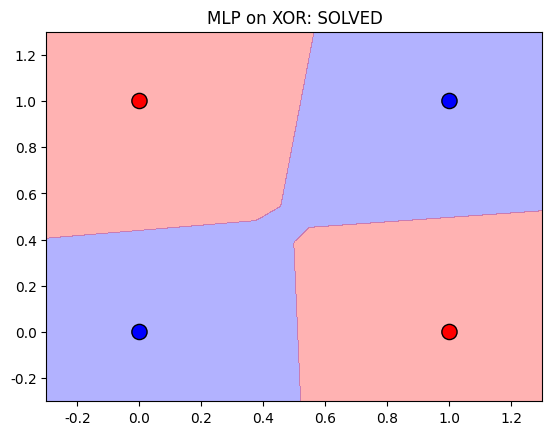

In [15]:
# 모델이 평면을 어떻게 나누는지(결정경계) 색으로 표시
def plot_boundary(model, title, filename):
  xx, yy = torch.meshgrid(torch.linspace(-0.3, 1.3, 200), # 격자 좌표 생성
                          torch.linspace(-0.3, 1.3, 200), indexing="xy")
  grid = torch.stack([xx.flatten(), yy.flatten()], dim=1) # 입력 데이터 형태 변환
  with torch.no_grad():
    zz = model(grid).reshape(xx.shape)
  plt.contourf(xx, yy, zz, levels = [0, 0.5, 1], alpha=0.3, colors=["blue", "red"]) # zz 예측값을 기준으로 0~0.5는 파란색, 0.5~1은 빨간색, 결정 경계 영역 채우기
  plt.scatter(X[:, 0], X[:, 1], c=["blue", "red", "red", "blue"],  s=120, edgecolors="black") # XOR 기준 색: 0=파랑, 1=빨강
  plt.title(title)
  plt.savefig(filename)
  plt.show()
  plt.close()

plot_boundary(mlp, "MLP on XOR: SOLVED", "plot2_xor_solved.png")